In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv
/kaggle/input/pm-111824185-at-04-02-2026-17-04-19/__script__.py
/kaggle/input/pm-111824185-at-04-02-2026-17-04-19/fonttools-4.62.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl
/kaggle/input/pm-111824185-at-04-02-2026-17-04-19/packaging-26.0-py3-none-any.whl
/kaggle/input/pm-111824185-at-04-02-2026-17-04-19/pyparsing-3.3.2-py3-none-any.whl
/kaggle/input/pm-111824185-at-04-02-2026-17-04-19/kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl
/kaggle/input/pm-111824185-at-04-02-2026-17-04-19/pillow-12.2.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl
/kaggle/input/pm-111824185-at-04-02-2026-17-04-19

In [2]:
# !pip install dython

In [3]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from dython import nominal

In [4]:
df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
pd.set_option('display.max_columns',None)

In [5]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

array([[<Axes: title={'center': 'Id'}>,
        <Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>],
       [<Axes: title={'center': 'YearBuilt'}>,
        <Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>],
       [<Axes: title={'center': 'TotalBsmtSF'}>,
        <Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>],
       [<Axes: title={'center': 'BsmtHalfBath'}>,
        <Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,

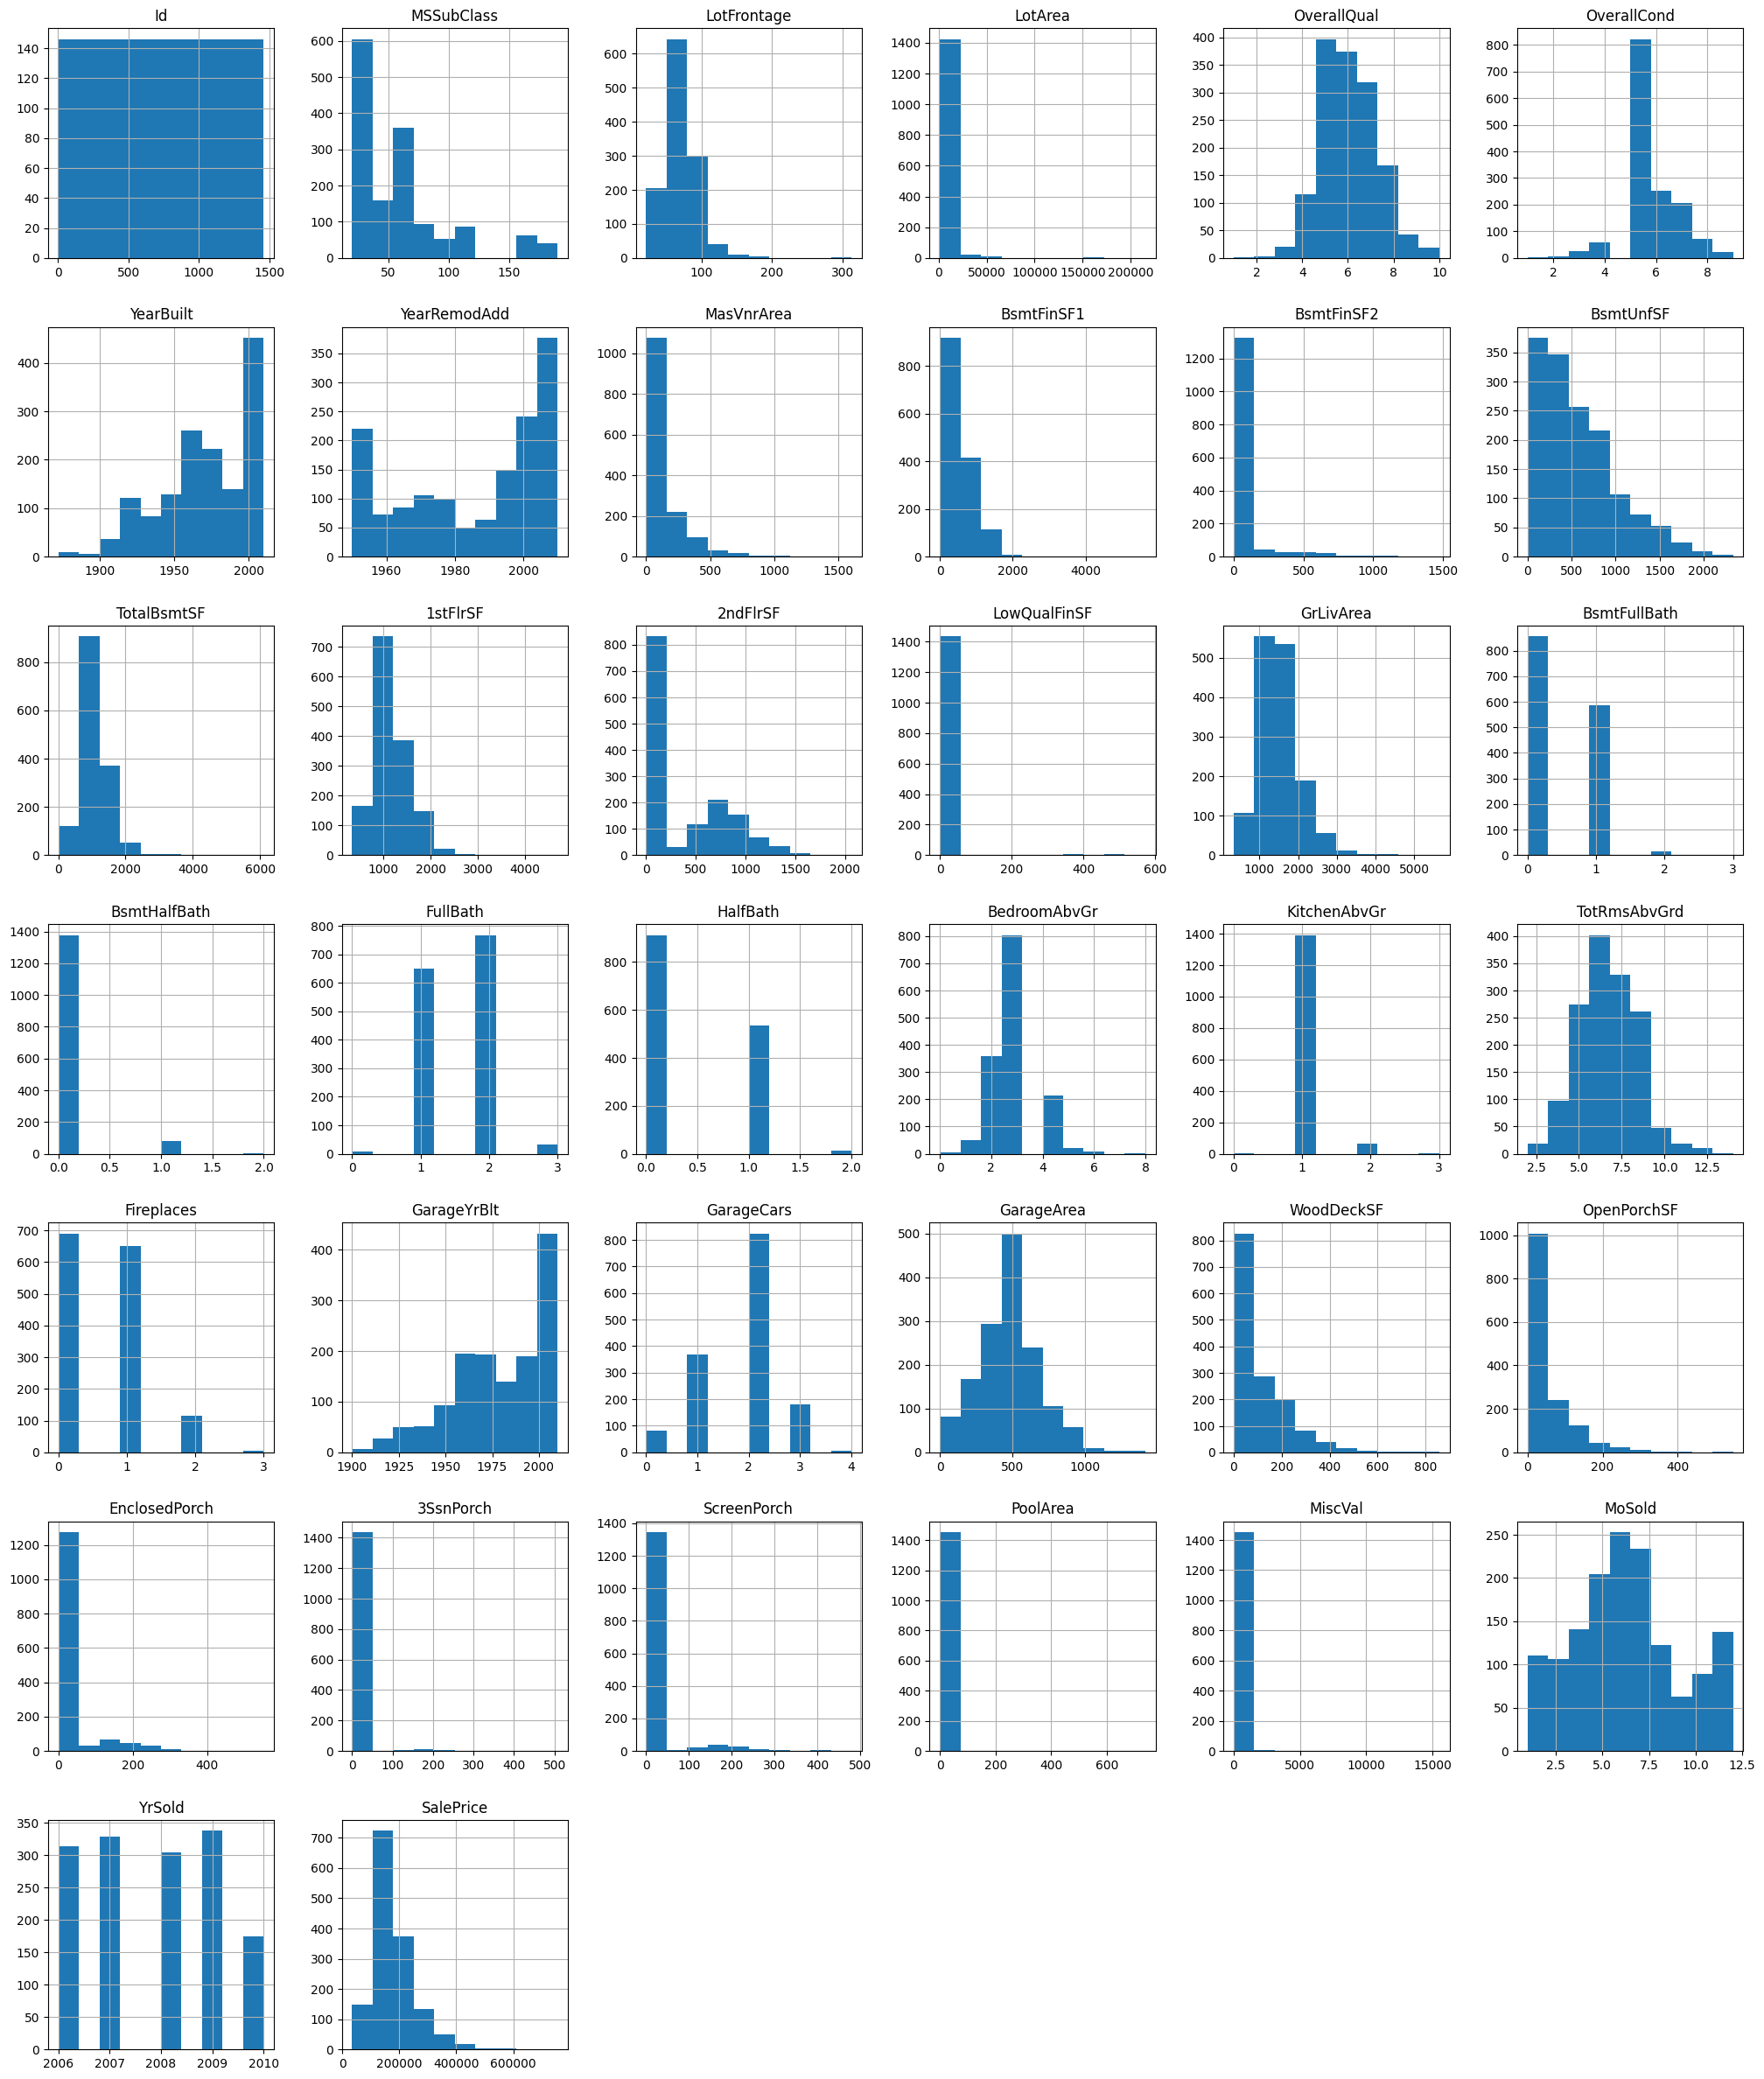

In [7]:
df.hist(figsize=(25,30))

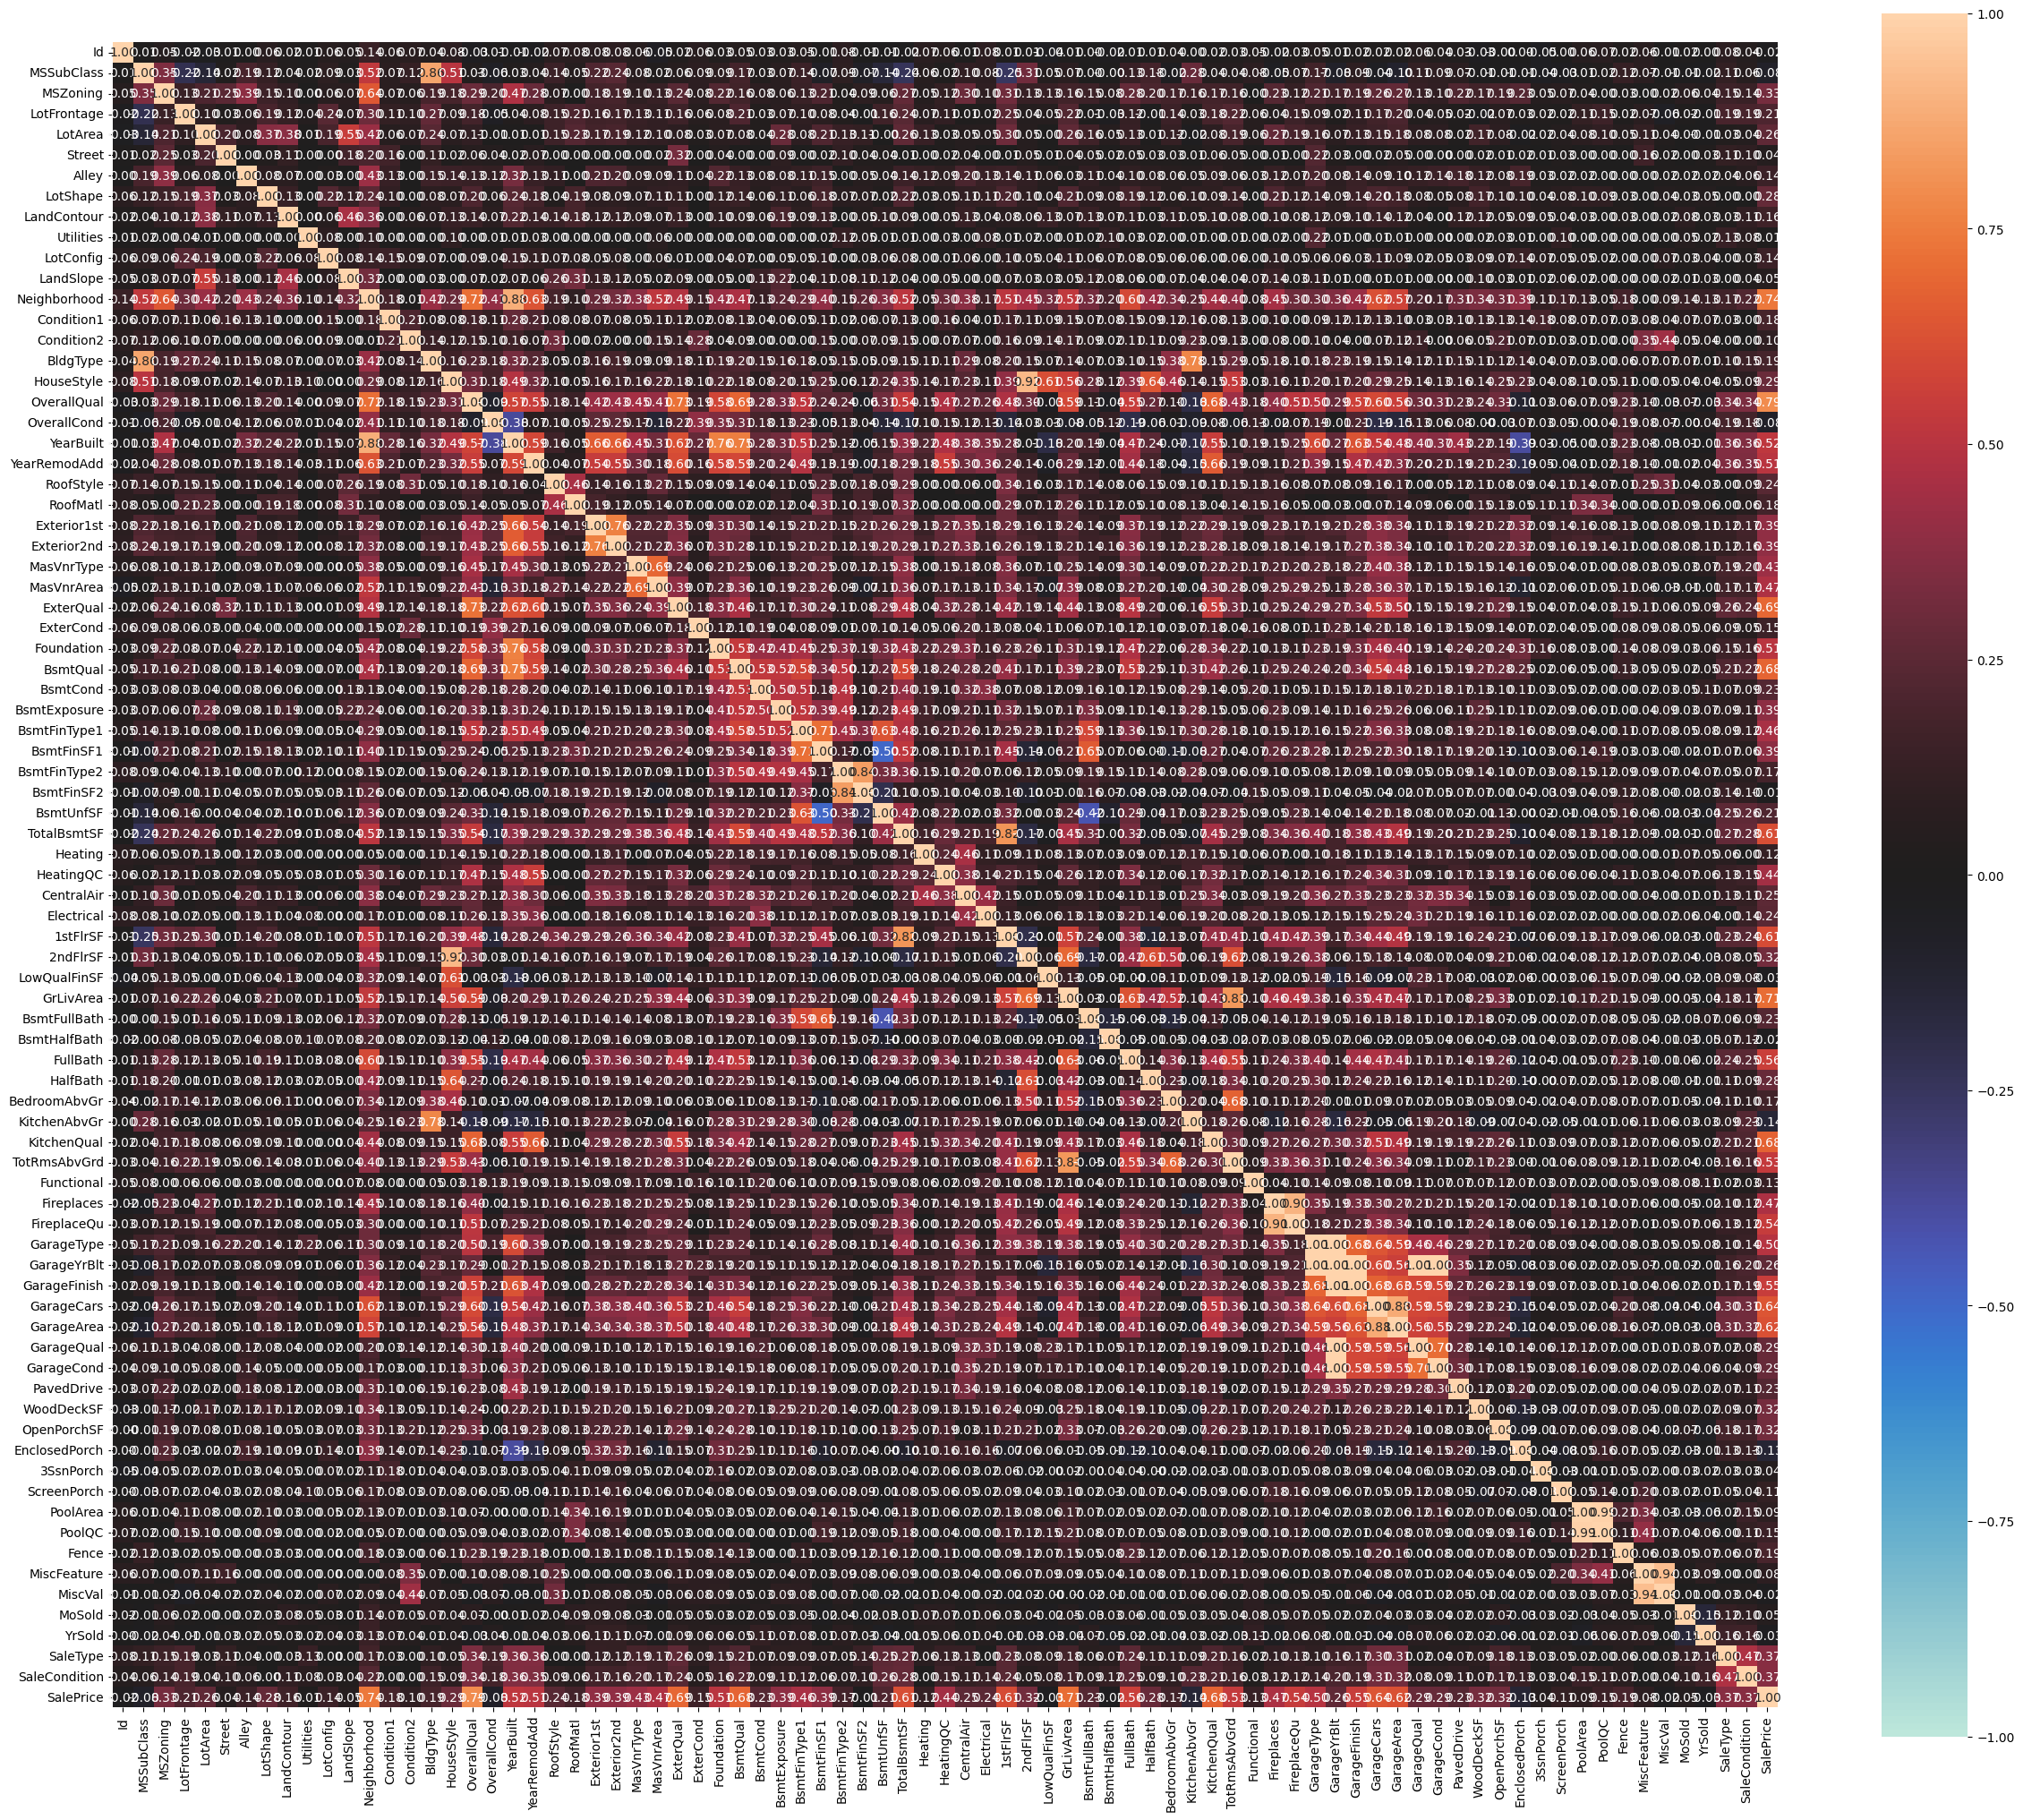

In [8]:
corr = nominal.associations(df,figsize=(30,25))
corr_matrix = corr['corr']
sale_corr = corr_matrix['SalePrice'].sort_values(ascending=False)

<Axes: >

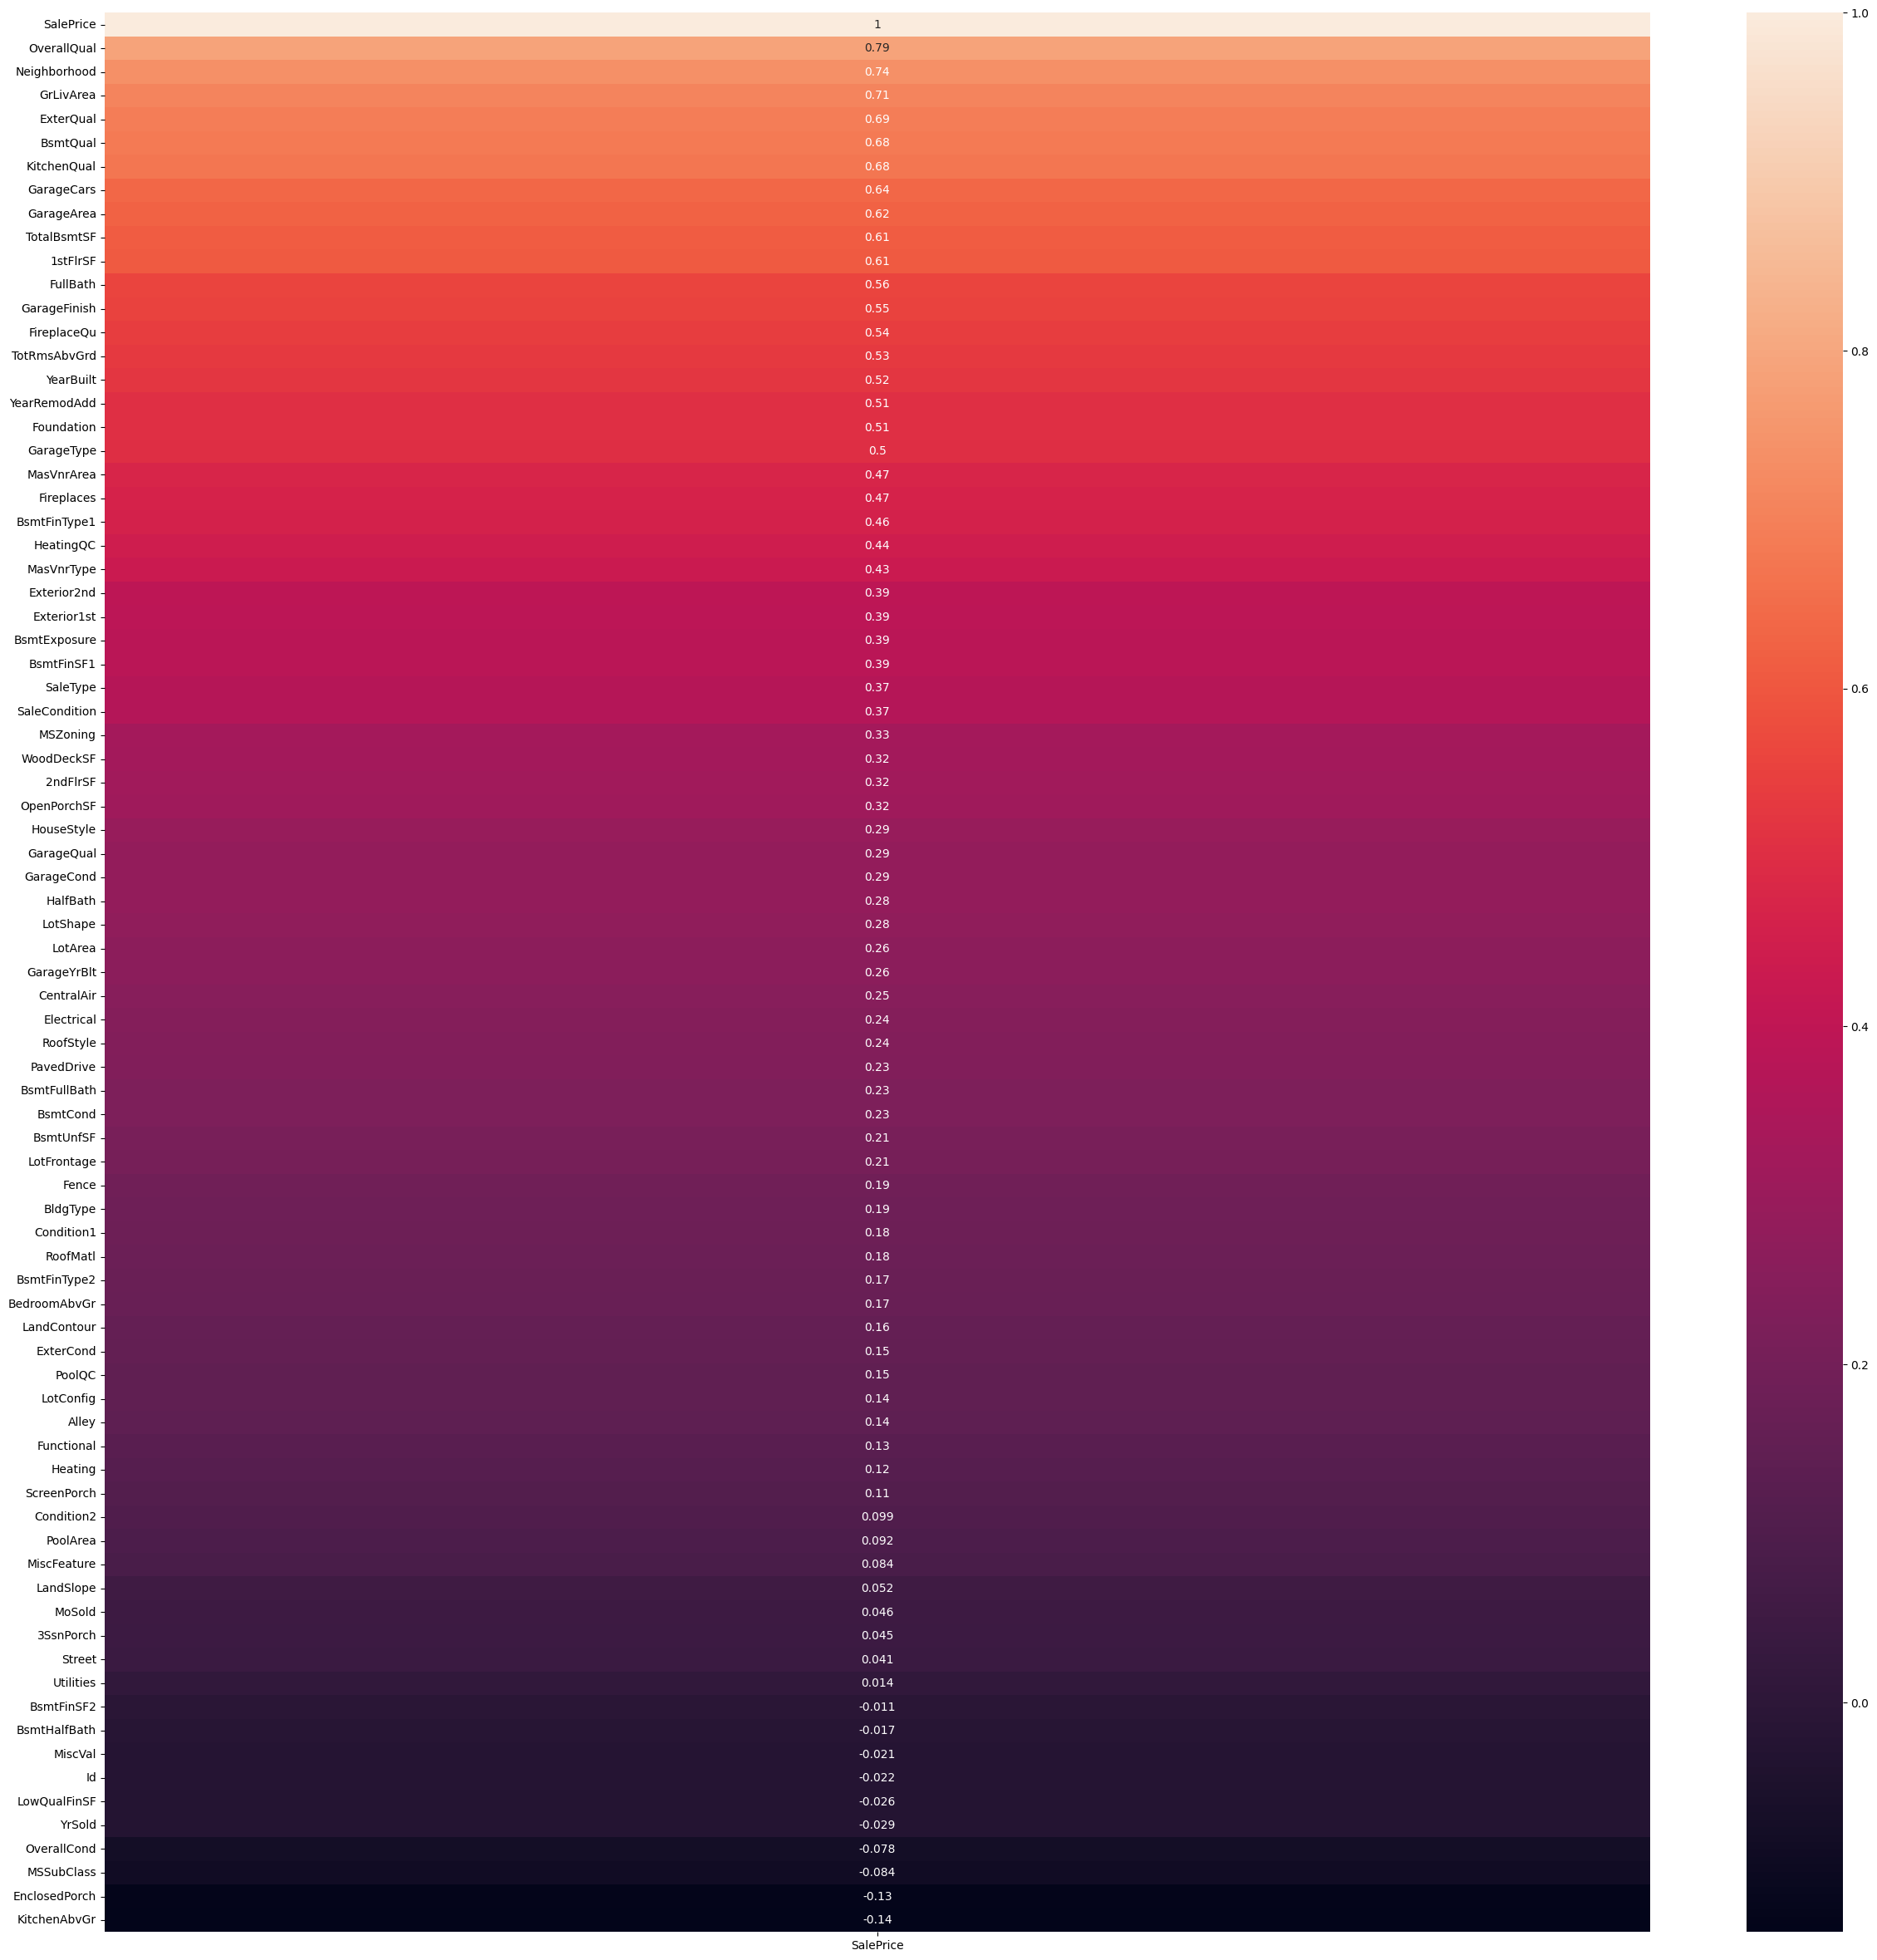

In [9]:
plt.figure(figsize=(30,30))
sns.heatmap(sale_corr.to_frame(),annot=True)

In [10]:
df['SalePrice_Category'] = pd.qcut(
    df['SalePrice'],
    q=4,
    labels=[0,1,2,3]
)
df['MSSubClass'] = df['MSSubClass'].astype(str)

In [11]:
from sklearn.preprocessing import FunctionTransformer,StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.compose import ColumnTransformer,TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

In [12]:
train_set, test_set = train_test_split(df, test_size=0.2,random_state=40,stratify = df['SalePrice_Category'])

In [13]:
for i in (train_set,test_set):
    i.drop(columns=['SalePrice_Category'],inplace=True)

In [14]:
train_set['MasVnrType'].value_counts()

MasVnrType
BrkFace    351
Stone      105
BrkCmn      11
Name: count, dtype: int64

In [15]:
class CustomMassonaryImputer(BaseEstimator,TransformerMixin):
    def __init__(self):
        pass
    def fit(self,x,y = None):
        self.type_area_dict = {}
        self.area_type_dict = {}
        values = x['MasVnrType'].unique()
        for i in values:
            self.type_area_dict[i] = x.loc[(x['MasVnrType'] == i),'MasVnrArea'].mean()
        values = x.loc[x['MasVnrType'].isnull(),'MasVnrArea'].unique()
        for i in values:
            if i == 0 or i == 1:
                self.area_type_dict[i] = 'None'
            else:
                self.area_type_dict[i] = x['MasVnrType'].mode()[0]
        return self
    def transform(self,x):
        for key,val in self.type_area_dict.items():
            x.loc[(x['MasVnrType'] == key)&(x['MasVnrArea'].isnull()),'MasVnrArea'] = val
        for key,val in self.area_type_dict.items():
            x.loc[x['MasVnrArea'] == key,'MasVnrType'] = val
        x.loc[(x['MasVnrType'].isnull())&(x['MasVnrArea'].isnull()),'MasVnrType'] = 'None'
        x.loc[x['MasVnrArea'].isnull(),'MasVnrArea'] = 0.0
        return x

In [16]:
class CustomBsmtImputer(BaseEstimator,TransformerMixin):
    def __init__(self):
        pass
    def fit(self,x,y = None):
        self.column_lst = ['BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2']
        self.mode_dict = {}
        for col in self.column_lst:
            self.mode_dict[col] = x[col].mode()[0]
        return self
    def transform(self,x):
        for col in self.column_lst:
            x.loc[x['TotalBsmtSF'] == 0,col] = 'NA'
            if col == 'BsmtFinType1':
                x.loc[(x[col].isnull())&(x['BsmtFinSF1']==0),col] = 'Unf'
            elif col == 'BsmtFinType2':
                x.loc[(x[col].isnull())&(x['BsmtFinSF2']==0),col] = 'Unf'
        for key,val in self.mode_dict.itms():
            x.loc[x[key].isnull(),key] = val
        return x

In [17]:
class CustomFireplaceQuImputer(BaseEstimator,TransformerMixin):
    def __init__(self):
        pass
    def fit(self,x,y = None):
        self.values = x['Fireplaces'].unique()
        self.value_dict = {}
        for val in self.values:
            if val == 0:
                self.value_dict[val] = 'None'
            else:
                self.value_dict[val] = x[x['Fireplaces'] == val]['FireplaceQu'].mode()[0]
        return self
    def transform(self,x):
        for key,val in self.value_dict.items():
            x.loc[(x['FireplaceQu'].isnull())&(x['Fireplaces'] == key),'FireplaceQu'] = val
        return x

In [18]:
class CustomGarageImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    def fit(self, x, y = None):
        self.lst = ['GarageType','GarageFinish','GarageQual','GarageCond']
        self.values_dict = {}
        self.values_dict['GarageYrBlt'] = x['GarageYrBlt'].median()
        for col in self.lst:
            self.values_dict[col] = x[col].mode()[0]
        return self
    def transform(self,x):
        for col in self.lst:
            x.loc[x['GarageArea']==0,col] = 'None'
        x.loc[x['GarageArea']==0,'GarageYrBlt'] = 0
        for col in self.lst:
            x.loc[x[col].isnull(),col] = self.values_dict[col]
        x.loc[x['GarageYrBlt'].isnull(),'GarageYrBlt'] = self.values_dict['GarageYrBlt']
        return x

In [19]:
class CustomPoolQCImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    def fit(self,x, y = None):
        self.poolqc_val = x['PoolQC'].mode()[0]
        return self
    def transform(self,x):
        x.loc[(x['PoolArea'] == 0) & (x['PoolQC'].isnull()),'PoolQC'] = 'NA'
        x.loc[x['PoolQC'].isnull(),'PoolQC'] = self.poolqc_val
        return x

In [20]:
class CustomMiscFeatureImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    def fit(self,x,y = None):
        self.mode_value = x['MiscFeature'].mode()[0]
        return self
    def transform(self,x):
        x.loc[(x['MiscValue']==0)&(x['MiscFeature'].isnull()),'MiscFeature'] = 'NA'
        x.loc[x['MiscFeature'].isnull(),'MiscFeature'] = self.mode_value
        return x

In [21]:
x_train = df.drop(columns=['SalePrice'])
y_train = df['SalePrice']

In [22]:
cat_pipeline_order = make_pipeline(
    SimpleImputer(strategy='constant',fill_value='None'),
    OrdinalEncoder(categories=[['NA','Po','Fa','Av','TA','Gd','Ex']],handle_unknown = 'use_encoded_value',unknown_value = -1)
)
num_pipeline = make_pipeline(
    SimpleImputer(strategy = 'median'),
    StandardScaler(with_mean=False)
)
cat_pipeline = make_pipeline(
    SimpleImputer(strategy='constant',fill_value='None'),
    OneHotEncoder(handle_unknown = 'ignore')
)

In [23]:
num_cols = x_train.select_dtypes(include = 'number').columns
qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 
             'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
qual_scale = ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
bsmt_fin_cols = ['BsmtFinType1', 'BsmtFinType2']
bsmt_fin_scale = ['NA', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']
bsmt_exp_cols = ['BsmtExposure']
bsmt_exp_scale = ['NA', 'No', 'Mn', 'Av', 'Gd']
gar_fin_cols = ['GarageFinish']
gar_fin_scale = ['NA', 'Unf', 'RFn', 'Fin']

nom_cols = [
    'MSZoning', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 
    'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'GarageType', 
    'MiscFeature', 'SaleType', 'SaleCondition','MSSubClass'
]
nom_pipeline = make_pipeline(
    SimpleImputer(strategy='constant', fill_value='None'),
    OneHotEncoder(handle_unknown='ignore')
)
num_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

In [24]:
def build_ordinal_pipeline(scale, num_columns):
    return make_pipeline(
        SimpleImputer(strategy='constant', fill_value='NA'),
        OrdinalEncoder(categories=[scale] * num_columns, 
                       handle_unknown='use_encoded_value', unknown_value=-1))

In [25]:
final_preprocessor = ColumnTransformer(transformers=[
    # Ordinal Pipelines
    ('qual_math', build_ordinal_pipeline(qual_scale, len(qual_cols)), qual_cols),
    ('bsmt_fin_math', build_ordinal_pipeline(bsmt_fin_scale, len(bsmt_fin_cols)), bsmt_fin_cols),
    ('bsmt_exp_math', build_ordinal_pipeline(bsmt_exp_scale, len(bsmt_exp_cols)), bsmt_exp_cols),
    ('gar_fin_math', build_ordinal_pipeline(gar_fin_scale, len(gar_fin_cols)), gar_fin_cols),
    
    # Nominal and Numerical Pipelines
    ('nom_math', nom_pipeline, nom_cols),
    ('num_math', num_pipeline, num_cols)
], remainder='drop')

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

In [27]:
target_pipeline = TransformedTargetRegressor(
    regressor = RandomForestRegressor(random_state=42),
    transformer = StandardScaler()
)
final_model = Pipeline(steps=[
    ('preprocessor',final_preprocessor),
    ('model',target_pipeline)]
)

In [28]:
test_data = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

In [29]:
final_model.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('qual_math', ...), ('bsmt_fin_math', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diff

In [30]:
predict = final_model.predict(test_data)

In [31]:
result_df = pd.DataFrame({
    'Id': test_data['Id'], 
    'SalePrice': predict
})
result_df.to_csv('Submission.csv',index=False)

In [32]:
data = pd.read_csv(r'/kaggle/working/Submission.csv')
data.head()

,Id,SalePrice
0,1461,127237.08
1,1462,155117.40
2,1463,184231.40
3,1464,182939.90
4,1465,196610.68
